# Figure 7: MQT Bench QNN on IBM hardware

For Comment 6 / Section 4.2.2: generate MQT QNN circuits, execute them with QED-C on IBM, and produce the **fidelity/depth metrics and volumetric plots**. No execution-time plots.

Based on the [external-circuits example](https://github.com/quantumcomputingdata/qedclib-examples/blob/main/integrations/external_circuits.py), using **4–14 qubits in steps of 2, three circuits per width**.

Select your Python environment with QED-C, MQT Bench, Qiskit, Aer, and IBM Runtime installed, then run top to bottom. Authentication uses your saved IBM account or `IBM_API_TOKEN` and `IBM_INSTANCE` environment variables. Use your Open Plan instance. The **Run benchmark** cell submits the hardware job; rerunning it submits another job.

In [1]:
min_qubits, max_qubits, skip_qubits = 4, 14, 2
max_circuits = 3
num_shots = 8192
seed = 2026
backend_name = None              # None = least busy accessible IBM device; or "ibm_..."
max_execution_time = 240          # QPU-seconds cap for the job, not a runtime estimate

## Setup

IBM [job mode](https://quantum.cloud.ibm.com/docs/en/guides/execution-modes) supports the Open Plan. These defaults submit 18 circuits / 147,456 shots in one job. Check your remaining IBM allowance before running; the time cap does not guarantee the job fits your remaining quota.

In [2]:
import os
from importlib.metadata import version
import numpy as np
from mqt.bench import get_benchmark, BenchmarkLevel
from qiskit import transpile
from qiskit_aer import Aer
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
import qedclib
from qedclib import metrics
from getpass import getpass

os.environ["IBM_INSTANCE"] = getpass("CRN: ")
os.environ["IBM_API_TOKEN"] = getpass("API key: ")

qedclib.initialize("qiskit")
ex = qedclib.execute
print({p: version(p) for p in ["mqt.bench", "qiskit", "qiskit-aer", "qiskit-ibm-runtime"]})

CRN:  ········
API key:  ········


QED-C Quantum Circuit Execution Library (qedclib 2.0.8)
{'mqt.bench': '2.2.1', 'qiskit': '2.1.0', 'qiskit-aer': '0.17.1', 'qiskit-ibm-runtime': '0.40.1'}


## 1. MQT circuit generation and fidelity reference

Each of the three circuits at a width gets reproducible, distinct parameter values. Repeated MQT default calls can otherwise give the same circuit. This preserves the paper's sizes/counts, not its original random parameters or numerical results.

Following the paper's noiseless Aer reference method, each **logical circuit** is run locally on `aer_simulator` with no noise model and `num_shots` shots. Its reference counts are stored in `ideal[group, cid]`. IBM hardware counts are compared with these reference counts in the handler. Both sets of counts have finite-shot effects, especially at larger widths. The local Aer runs do not use your IBM allowance.

In [3]:
assert 2 <= min_qubits <= max_qubits <= 16
assert skip_qubits > 0 and max_circuits > 0 and num_shots > 0
circuits, ideal = {}, {}
ideal_simulator = Aer.get_backend("aer_simulator")
for n in range(min_qubits, max_qubits + 1, skip_qubits):
    group = str(n)
    circuits[group] = {}
    for i in range(max_circuits):
        cid = str(i)
        qc = get_benchmark("qnn", BenchmarkLevel.ALG, n, random_parameters=False)
        rng = np.random.default_rng(seed + 1000 * n + i)
        assert qc.num_parameters > 0, "MQT must return symbolic QNN parameters."
        qc = qc.assign_parameters(rng.uniform(0, 2 * np.pi, qc.num_parameters))
        qc.name = f"qnn_{n}q_{i}"
        circuits[group][cid] = qc
        ideal_circuit = transpile(qc, ideal_simulator, seed_transpiler=seed)
        ideal[group, cid] = ideal_simulator.run(
            ideal_circuit, shots=num_shots, noise_model=None,
            seed_simulator=seed + 100000 + 1000 * n + i
        ).result().get_counts()

def execution_handler(qc, result, group, cid, shots):
    counts = result.get_counts()
    assert sum(counts.values()) == shots, "Incomplete results."
    fidelity = metrics.polarization_fidelity(counts, ideal[str(group), str(cid)])
    # This returns both 'fidelity' (polarization) and 'hf_fidelity' (Hellinger).
    metrics.store_metric(group, cid, "fidelity", fidelity)

print(f"Prepared {sum(map(len, circuits.values()))} QNN circuits.")

Prepared 18 QNN circuits.


## 2. Connect to IBM

The backend is passed to QED-C with a job-mode Sampler. QED-C handles hardware transpilation and execution. Twirling and dynamical decoupling are disabled for this unmitigated run; no synthetic noise model is used.

In [4]:
account = {"plans_preference": ["open"]}
if os.environ.get("IBM_INSTANCE"):
    account["instance"] = os.environ["IBM_INSTANCE"]
if os.environ.get("IBM_API_TOKEN"):
    account.update(channel="ibm_quantum_platform", token=os.environ["IBM_API_TOKEN"])
service = QiskitRuntimeService(**account)
backend = (service.backend(backend_name) if backend_name else
           service.least_busy(operational=True, simulator=False, min_num_qubits=max_qubits))
assert not backend.configuration().simulator and backend.num_qubits >= max_qubits

ex.auto_warmup = False
ex.parallel_execution = False
ex.set_execution_target(backend.name, provider_backend=backend,
                        exec_options={"noise_model": None, "optimization_level": 1})
ex.sampler = SamplerV2(mode=backend, options={
    "max_execution_time": max_execution_time,
    "dynamical_decoupling": {"enable": False},
    "twirling": {"enable_gates": False, "enable_measure": False},
})
print("IBM device:", backend.name)

IBM device: ibm_kingston


## 3. Run benchmark

This cell submits one job and waits for the results. IBM queue time can be long.

In [5]:
metrics.init_metrics()
ex.init_execution(execution_handler)
ex.basis_selector = 1            # QED-C normalized basis: rx, ry, rz, cx
ex.compute_all_circuit_metrics(circuits)
ex.submit_circuits(circuits, num_shots=num_shots)

# QED-C reports execution/handler errors without always raising: check before plotting.
for group, group_circuits in circuits.items():
    for cid in group_circuits:
        assert "fidelity" in metrics.circuit_metrics[group][cid], "Missing results; inspect the error above."
        assert "hf_fidelity" in metrics.circuit_metrics[group][cid]
metrics.finalize_all_groups()
metrics.end_metrics()

... execution starting at Sep 28, 2026 16:55:22 UTC
************
Average Circuit Algorithmic Depth, xi for the 4 qubit group = 10, 0.111
Average Normalized Transpiled Depth, xi, 2q gates for the 4 qubit group = 8, 0.158, 3.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0, 2.838, 2.206 secs
Average Transpiling, Validating, Running Times for group 4 = 1.941, 0.001, 47.183 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.922, 0.824

************
Average Circuit Algorithmic Depth, xi for the 6 qubit group = 12, 0.122
Average Normalized Transpiled Depth, xi, 2q gates for the 6 qubit group = 10, 0.172, 5.0
Average Creation, Elapsed, Execution Time for the 6 qubit group = 0, 2.838, 2.206 secs
Average Transpiling, Validating, Running Times for group 6 = 1.941, 0.001, 47.183 secs
Average Hellinger, Normalized Fidelity for the 6 qubit group = 0.907, 0.791

************
Average Circuit Algorithmic Depth, xi for the 8 qubit group = 14, 0.127
Average Normal

## 4. Figure 7 plots

Depth and two-qubit counts use QED-C's normalized basis. Fidelity error bars use QED-C's standard error across the three circuits, not a shot-noise confidence interval. The volumetric plot positions the QNN circuits; it is not a Quantum Volume measurement.

The two PDFs are saved under `__images/<IBM device>/` as **`qnn-metrics.pdf`** and **`qnn-vplot.pdf`**. QED-C metrics, including job IDs, are saved under `__data/`. Subsequent runs on the same backend replace the figure files.

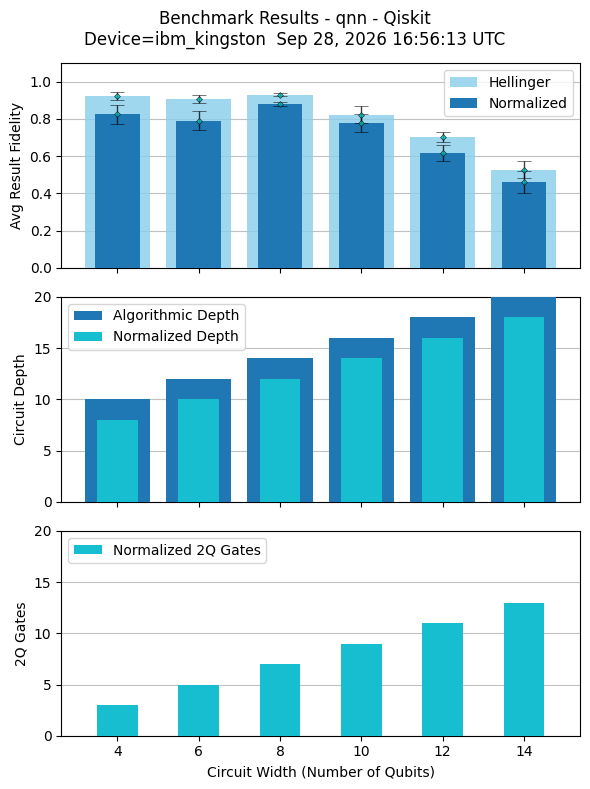

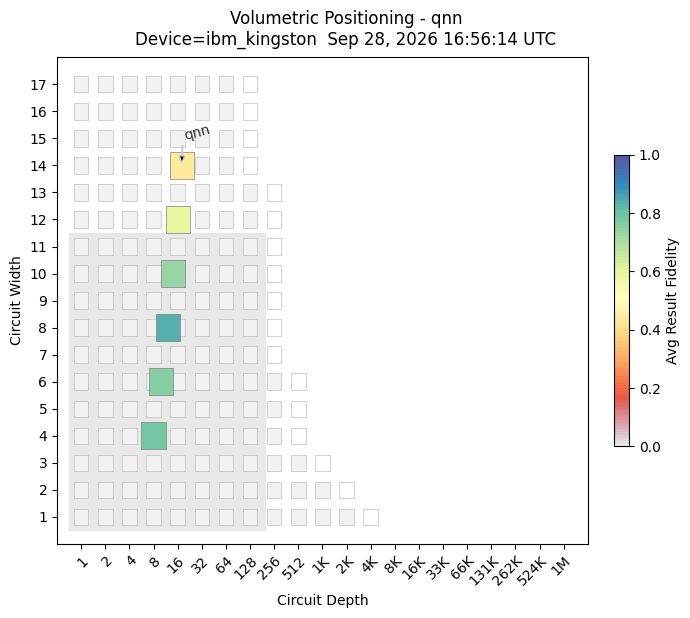

Figure PDFs: /Users/neerpatel/Desktop/repos/QC-App-Oriented-Benchmarks/__images/ibm_kingston


In [6]:
metrics.set_plot_subtitle(f"Device = {backend.name}")
metrics.QV = 0
metrics.aq_mode = 0
metrics.save_plot_images = True
metrics.show_plot_images = True
metrics.do_volumetric_plots = True
metrics.save_app_metrics("qnn")
metrics.plot_metrics("Benchmark Results - qnn - Qiskit",
                     filters=["fidelity", "hf_fidelity", "depth", "2q", "vbplot"])
print(f"Figure PDFs: {os.path.abspath('__images/' + backend.name)}")